# Deep Image Prior (DIP) — Simple MRI Reconstruction
### Using Shepp-Logan Phantom (no mask, no coils)
This notebook demonstrates the simplest possible DIP applied to MRI reconstruction.
It uses a single CNN to reconstruct an image from noise by matching its Fourier space.

In [ ]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import optax
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

## 1. Generate simulated data (Shepp-Logan phantom)

In [ ]:
# Image size
N = 128

# Generate Shepp-Logan phantom and resize
phantom = resize(shepp_logan_phantom(), (N, N), anti_aliasing=True)
x_true = jnp.asarray(phantom)

# Full k-space (no mask, no coils)
k_true = jnp.fft.fft2(x_true)

plt.imshow(x_true, cmap='gray')
plt.title("Ground Truth Phantom")
plt.axis('off')
plt.show()

## 2. Define a U-Net DIP network
A simple 3-layer convolutional network that maps noise to an image.

In [ ]:
import jax
import jax.numpy as jnp
import flax.nnx as nnx

class UNetBlock(nnx.Module):
    """A small conv block: Conv -> ReLU -> Conv -> ReLU."""
    def __init__(self, in_ch, out_ch, rngs):
        self.conv1 = nnx.Conv(in_ch, out_ch, (3, 3), padding="SAME", rngs=rngs)
        self.conv2 = nnx.Conv(out_ch, out_ch, (3, 3), padding="SAME", rngs=rngs)

    def __call__(self, x):
        x = jax.nn.relu(self.conv1(x))
        x = jax.nn.relu(self.conv2(x))
        return x


class UNet(nnx.Module):
    def __init__(self, rngs):
        # Encoder
        self.enc1 = UNetBlock(1, 32, rngs)
        self.enc2 = UNetBlock(32, 64, rngs)
        self.enc3 = UNetBlock(64, 128, rngs)

        # Decoder
        self.dec2 = UNetBlock(128 + 64, 64, rngs)
        self.dec1 = UNetBlock(64 + 32, 32, rngs)

        # Final conv (linear output)
        self.final = nnx.Conv(32, 1, (3, 3), padding="SAME", rngs=rngs)

    def __call__(self, x):
        # Encoder
        x1 = self.enc1(x)
        x2 = self.enc2(nnx.avg_pool(x1, (2, 2), (2, 2)))  # down 2×
        x3 = self.enc3(nnx.avg_pool(x2, (2, 2), (2, 2)))  # down 4×

        # Bottleneck
        y = x3

        # Decoder (upsample + concat)
        y = jax.image.resize(y, (y.shape[0], x2.shape[1], x2.shape[2], y.shape[3]), "nearest")
        y = jnp.concatenate([y, x2], axis=-1)
        y = self.dec2(y)

        y = jax.image.resize(y, (y.shape[0], x1.shape[1], x1.shape[2], y.shape[3]), "nearest")
        y = jnp.concatenate([y, x1], axis=-1)
        y = self.dec1(y)

        # Output (linear)
        y = self.final(y)
        return y


## 3. Initialize the network and input noise

In [ ]:
key = jax.random.key(0)
model = UNet(nnx.Rngs(key))

# Fixed random noise
z = jax.random.normal(key, (1, N, N, 1))

# Test forward pass
x_init = model(z)[0, :, :, 0]
plt.imshow(x_init, cmap='gray')
plt.title("Initial Output (Random)")
plt.axis('off')
plt.show()

## 4. Define the loss function (Fourier-space MSE)

Incluir pesos que balanceen altas y bajas frecuencias es muy útil

In [ ]:
def loss_fn(model):
    x_pred = model(z)[0, :, :, 0]
    k_pred = jnp.fft.fft2(x_pred)
    ky, kx = jnp.meshgrid(jnp.fft.fftfreq(N), jnp.fft.fftfreq(N))
    freq_weight = 1.0 + 5.0 * jnp.sqrt(kx**2 + ky**2)
    loss = jnp.mean(jnp.abs(freq_weight * (k_pred - k_true))**2)

    return loss


## 5. Training loop

In [ ]:
import optax

optimizer = nnx.Optimizer(
    model=model,
    tx=optax.adam(1e-3),
    wrt=nnx.Param
)

n_steps = 1_000
losses = []

for step in range(n_steps):
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(model, grads)
    losses.append(loss)

    if step % 100 == 0:
        print(f"Step {step}, Loss: {loss:.4e}")
        x_reco = model(z)[0, :, :, 0]
        plt.imshow(x_reco, cmap="gray")
        plt.show()

## 6. Visualize reconstruction and training curve

In [ ]:
x_reco = model(z)[0, :, :, 0]


plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(x_true, cmap='gray')
plt.title("x_true")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(x_reco, cmap='gray')
plt.title("x_reco")
plt.axis('off')

plt.subplot(1,3,3)
plt.plot(losses)
plt.title("Loss curve")
plt.show()

## 7. Inspect learned parameters (kernels)
Let's print the shape of the learned kernels to verify they are shared.

In [ ]:
def print_param_shapes(state, prefix=""):
    for k, v in state.items():
        if isinstance(v, nnx.State):
            print_param_shapes(v, prefix + k + ".")
        else:
            print(prefix + k, v.shape)

params = nnx.state(model, nnx.Param)
print_param_shapes(params)


You can now try applying the same trained model to another noise `z2` with a different shape — the same weights are reused thanks to the convolutional structure.

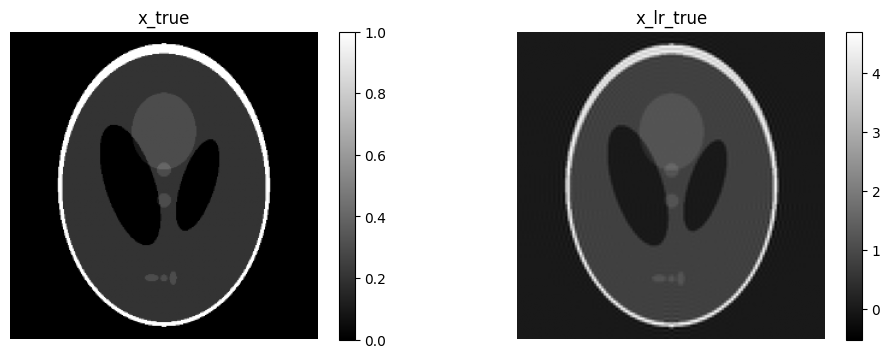

In [9]:
# ===============================================================
# 2. Phantom and Fourier model
# ===============================================================
N = 256
phantom = shepp_logan_phantom()
x_true = resize(phantom, (N, N), anti_aliasing=True)

# Super-resolution factor
s = 2
N_LR = N // s

# Fourier transform utilities
def fft2c(x):  # centered 2D FFT
    return jnp.fft.fftshift(jnp.fft.fft2(jnp.fft.ifftshift(x)))

def ifft2c(k):
    return jnp.fft.fftshift(jnp.fft.ifft2(jnp.fft.ifftshift(k)))

# Ideal LR data (bandlimited + decimated)
def downsample_sinc(x, s):
    k = fft2c(x)
    center = N // 2
    half = N_LR // 2
    k_lr = k[center-half:center+half, center-half:center+half]
    return jnp.real(ifft2c(k_lr)), k_lr

x_lr_true, F_lr_true = downsample_sinc(x_true, s)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.imshow(x_true, cmap='gray')
plt.title("x_true")
plt.colorbar()
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(x_lr_true, cmap='gray')
plt.title("x_lr_true")
plt.colorbar()
plt.axis('off')

plt.show()


# Experiment with undersampled mask

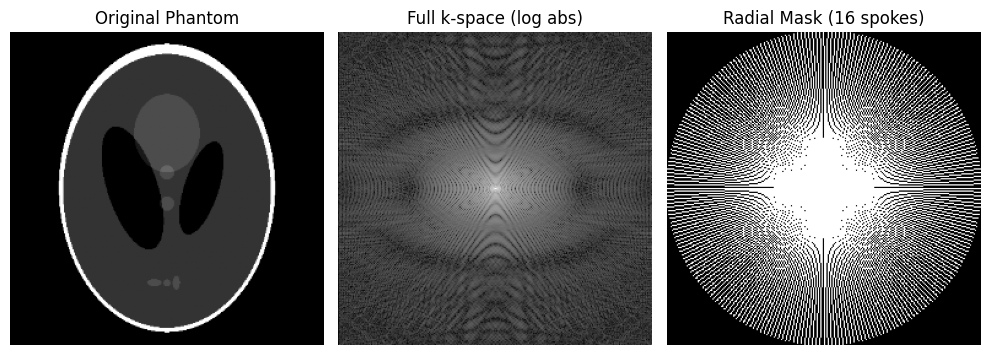

In [1]:
import numpy as np
import jax.numpy as jnp
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
import matplotlib.pyplot as plt

# 1. Generate Shepp–Logan phantom
N = 256
phantom = shepp_logan_phantom()
phantom = resize(phantom, (N, N), anti_aliasing=True)
x_true = jnp.array(phantom, dtype=jnp.float32)

# 2. Compute full k-space (complex)
k_true = jnp.fft.fft2(x_true)

# 3. Generate radial mask (spokes)
def radial_points_mask(N, n_lines=16, n_points=None):
    if n_points is None:
        n_points = N
    center = (N - 1) / 2.0
    radius = N / 2.0
    mask = np.zeros((N, N), dtype=np.float32)
    angles = np.linspace(0, np.pi, n_lines, endpoint=False)
    r = np.linspace(-radius, radius, n_points)
    for a in angles:
        x = center + r * np.cos(a)
        y = center + r * np.sin(a)
        x_idx = np.clip(np.round(x).astype(int), 0, N - 1)
        y_idx = np.clip(np.round(y).astype(int), 0, N - 1)
        mask[y_idx, x_idx] = 1.0
    return jnp.array(mask)

M = radial_points_mask(N, n_lines=128)
# M = jnp.ones((N,N))

# 4. Apply mask to simulate undersampled k-space
y = M * k_true

# 5. Display
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(x_true, cmap='gray')
plt.title("Original Phantom")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(jnp.log1p(jnp.abs(jnp.fft.fftshift(k_true))), cmap='gray')
plt.title("Full k-space (log abs)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(M, cmap='gray')
plt.title("Radial Mask (16 spokes)")
plt.axis('off')

plt.tight_layout()
plt.show()

In [30]:
def loss_fn(model):
    # Imagen predicha y FFT
    x_pred = model(z, training=True)[0, :, :, 0]
    k_pred = jnp.fft.fft2(x_pred)

    # Coordenadas de frecuencia normalizadas
    ky, kx = jnp.meshgrid(jnp.fft.fftfreq(N), jnp.fft.fftfreq(N))
    r = jnp.sqrt(kx**2 + ky**2)

    # Peso: más grande en altas frecuencias
    # Usa una forma suave para evitar discontinuidades
    freq_weight = 1.0 + 5.0 * r  # o r**gamma, gamma≈0.5-1 según pruebas

    # Diferencia ponderada en posiciones muestreadas
    diff = M * (k_pred - y)
    weighted_diff = freq_weight * diff

    # Pérdida final
    loss = jnp.sum(jnp.abs(weighted_diff)**2) / (jnp.sum(M) + 1e-8)
    return loss


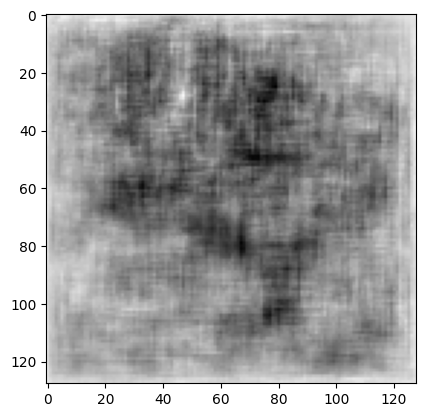

In [31]:
import jax
key = jax.random.key(0)
from flax import nnx
from misc_nnx import DecoderNNX
import matplotlib.pyplot as plt

z = jax.random.normal(key, (1, 8, 8, 1))

model = DecoderNNX(
    in_channels=1,
    features=64,
    levels=3,       # 8→16→32→64→128
    out_features=1,
    rngs=nnx.Rngs(key)
)
x_init = model(z, training=False)[0, :, :, 0]
plt.imshow(x_init, cmap="gray")

Step     0, Loss: 5.7255e+00


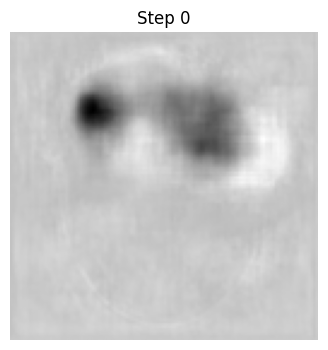

Step    10, Loss: 1.7701e+02
Step    20, Loss: 6.0673e+01
Step    30, Loss: 2.3630e+01
Step    40, Loss: 1.0949e+01
Step    50, Loss: 5.6159e+00
Step    60, Loss: 3.7828e+00
Step    70, Loss: 2.5674e+00
Step    80, Loss: 1.8266e+00
Step    90, Loss: 1.8212e+00
Step   100, Loss: 1.1466e+00


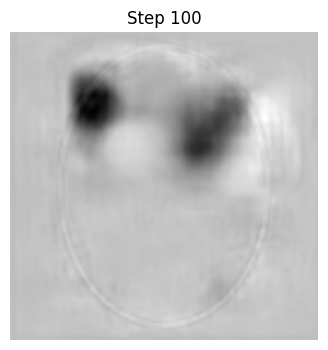

Step   110, Loss: 8.6768e-01
Step   120, Loss: 7.4514e-01
Step   130, Loss: 8.1581e-01
Step   140, Loss: 8.9128e-01
Step   150, Loss: 8.3973e-01
Step   160, Loss: 5.0720e-01
Step   170, Loss: 4.3119e-01
Step   180, Loss: 4.6841e-01
Step   190, Loss: 4.0409e-01
Step   200, Loss: 2.7988e-01


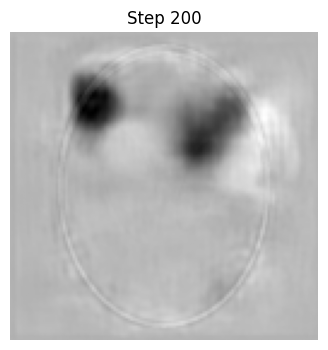

Step   210, Loss: 1.5522e+00
Step   220, Loss: 4.3899e+00
Step   230, Loss: 1.6298e+00
Step   240, Loss: 7.0851e-01
Step   250, Loss: 3.7352e-01
Step   260, Loss: 2.4310e-01
Step   270, Loss: 2.0679e-01
Step   280, Loss: 1.6175e-01
Step   290, Loss: 1.1323e-01
Step   300, Loss: 7.7900e-01


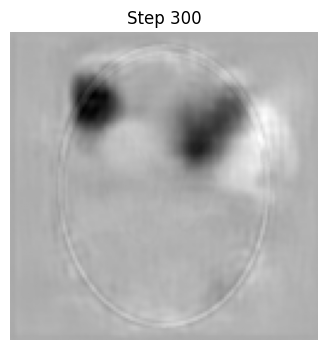

Step   310, Loss: 4.1862e-01
Step   320, Loss: 1.6567e-01
Step   330, Loss: 1.0241e-01
Step   340, Loss: 1.7825e-01
Step   350, Loss: 1.1665e-01
Step   360, Loss: 8.7381e-02
Step   370, Loss: 1.4494e-01
Step   380, Loss: 1.7938e-01
Step   390, Loss: 9.1683e-02
Step   400, Loss: 7.5419e-02


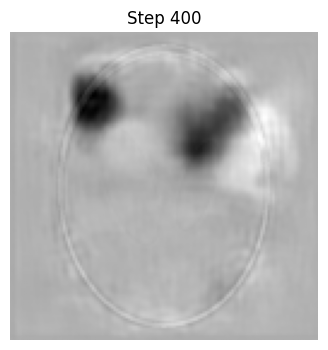

Step   410, Loss: 6.6888e-02
Step   420, Loss: 5.7597e-01
Step   430, Loss: 8.9821e-01
Step   440, Loss: 5.0973e-01
Step   450, Loss: 2.6165e-01
Step   460, Loss: 1.1660e-01
Step   470, Loss: 6.1066e-02
Step   480, Loss: 5.0842e-02
Step   490, Loss: 1.2108e-01
Step   500, Loss: 6.2369e-02


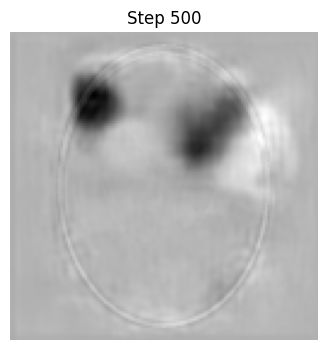

Step   510, Loss: 4.1154e-02
Step   520, Loss: 2.9282e-02
Step   530, Loss: 2.5249e-02
Step   540, Loss: 2.7503e-02
Step   550, Loss: 6.0752e-02
Step   560, Loss: 9.0276e-01
Step   570, Loss: 2.3611e-01
Step   580, Loss: 1.5298e-01
Step   590, Loss: 7.0693e-02
Step   600, Loss: 4.4737e-02


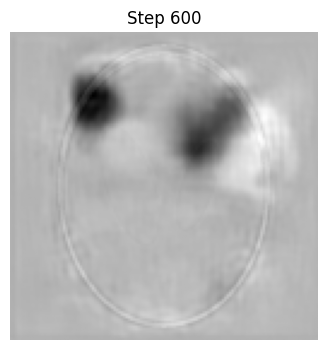

Step   610, Loss: 3.4976e-02
Step   620, Loss: 2.0394e-02
Step   630, Loss: 1.2751e-02
Step   640, Loss: 1.5572e-01
Step   650, Loss: 3.7104e+00
Step   660, Loss: 3.8852e+00
Step   670, Loss: 1.1892e+00
Step   680, Loss: 4.6854e-01
Step   690, Loss: 1.9931e-01
Step   700, Loss: 9.0285e-02


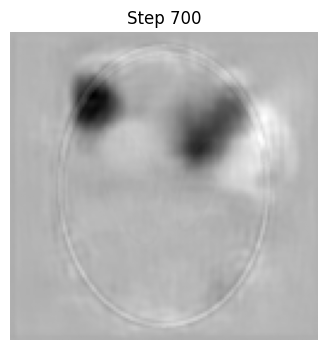

Step   710, Loss: 5.5863e-02
Step   720, Loss: 3.3242e-02
Step   730, Loss: 3.1019e-02
Step   740, Loss: 6.1718e-02
Step   750, Loss: 3.7099e-02
Step   760, Loss: 2.0465e-02
Step   770, Loss: 1.5263e-02
Step   780, Loss: 6.7941e-02
Step   790, Loss: 1.6113e-01
Step   800, Loss: 7.3787e-02


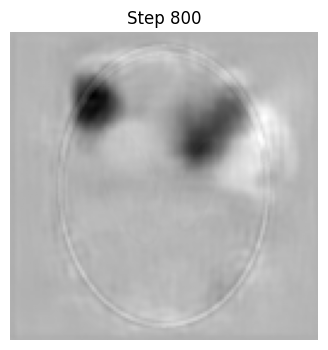

Step   810, Loss: 3.3236e-02
Step   820, Loss: 1.9377e-02
Step   830, Loss: 1.1223e-02
Step   840, Loss: 1.0743e-02
Step   850, Loss: 8.4989e-03
Step   860, Loss: 2.5945e-02
Step   870, Loss: 1.7691e-02
Step   880, Loss: 2.4423e-02
Step   890, Loss: 2.1944e-01
Step   900, Loss: 6.3991e-01


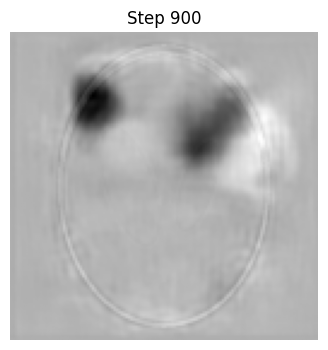

Step   910, Loss: 2.7900e-01
Step   920, Loss: 1.0968e-01
Step   930, Loss: 6.4876e-02
Step   940, Loss: 2.7032e-02
Step   950, Loss: 1.1729e-02
Step   960, Loss: 6.3777e-03
Step   970, Loss: 6.5883e-03
Step   980, Loss: 7.4622e-03
Step   990, Loss: 1.0145e-02
Step  1000, Loss: 6.1534e-03


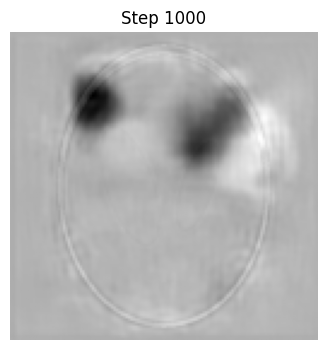

Step  1010, Loss: 5.3804e-03
Step  1020, Loss: 5.0681e-03
Step  1030, Loss: 4.6452e-03
Step  1040, Loss: 4.1410e-03
Step  1050, Loss: 5.9472e-03
Step  1060, Loss: 8.4771e-02
Step  1070, Loss: 5.3989e-01
Step  1080, Loss: 1.2438e-01
Step  1090, Loss: 6.9843e-02
Step  1100, Loss: 2.6417e-02


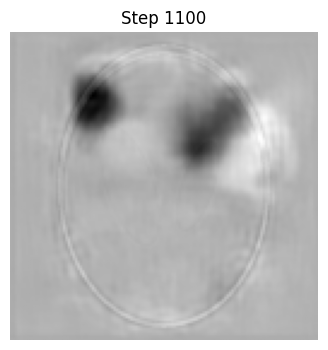

Step  1110, Loss: 1.7216e-02
Step  1120, Loss: 1.0359e-02
Step  1130, Loss: 4.9557e-03
Step  1140, Loss: 4.8902e-03
Step  1150, Loss: 4.0299e-03
Step  1160, Loss: 4.1274e-03
Step  1170, Loss: 3.2995e-03
Step  1180, Loss: 7.9736e-03
Step  1190, Loss: 1.1672e-02
Step  1200, Loss: 7.4952e-03


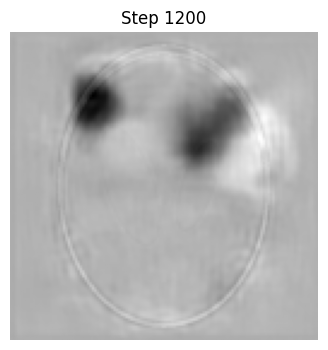

Step  1210, Loss: 1.5598e-01
Step  1220, Loss: 6.8931e-01
Step  1230, Loss: 6.6234e-01
Step  1240, Loss: 2.4739e-01
Step  1250, Loss: 1.0427e-01
Step  1260, Loss: 4.7268e-02
Step  1270, Loss: 2.2122e-02
Step  1280, Loss: 1.0737e-02
Step  1290, Loss: 8.8845e-03
Step  1300, Loss: 1.2715e-02


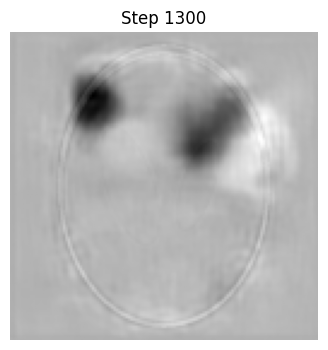

Step  1310, Loss: 9.2055e-02
Step  1320, Loss: 2.4484e-02
Step  1330, Loss: 1.2970e-02
Step  1340, Loss: 8.9338e-03
Step  1350, Loss: 1.6681e-02
Step  1360, Loss: 5.0347e-02
Step  1370, Loss: 6.7244e-02
Step  1380, Loss: 4.8790e-02
Step  1390, Loss: 2.1935e-02
Step  1400, Loss: 3.2635e-02


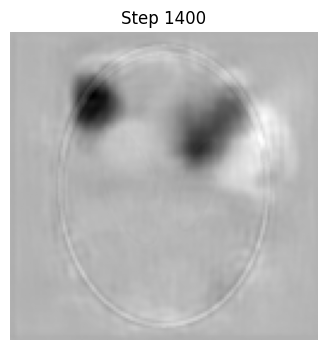

Step  1410, Loss: 2.3980e-01
Step  1420, Loss: 4.3413e+00
Step  1430, Loss: 7.9133e+01
Step  1440, Loss: 2.2088e+01
Step  1450, Loss: 6.9809e+00
Step  1460, Loss: 3.2930e+00
Step  1470, Loss: 1.7712e+00
Step  1480, Loss: 1.0906e+00
Step  1490, Loss: 7.9560e-01
Step  1500, Loss: 5.7813e-01


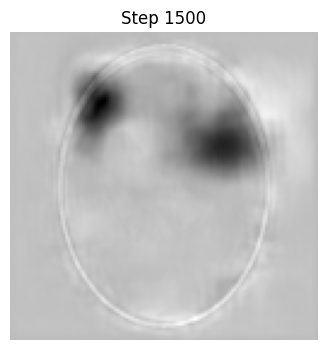

Step  1510, Loss: 4.8279e-01
Step  1520, Loss: 3.8455e-01
Step  1530, Loss: 3.5339e-01
Step  1540, Loss: 2.8411e-01
Step  1550, Loss: 2.4712e-01
Step  1560, Loss: 2.4123e-01
Step  1570, Loss: 1.9678e-01
Step  1580, Loss: 1.7359e-01
Step  1590, Loss: 1.7682e-01
Step  1600, Loss: 1.5243e-01


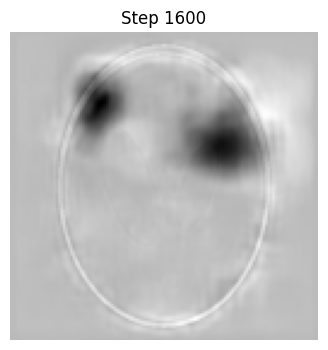

Step  1610, Loss: 1.2998e-01
Step  1620, Loss: 1.1708e-01
Step  1630, Loss: 1.0963e-01
Step  1640, Loss: 1.2130e-01
Step  1650, Loss: 1.0121e-01
Step  1660, Loss: 9.8840e-02
Step  1670, Loss: 9.1900e-02
Step  1680, Loss: 7.8419e-02
Step  1690, Loss: 7.2221e-02
Step  1700, Loss: 6.5223e-02


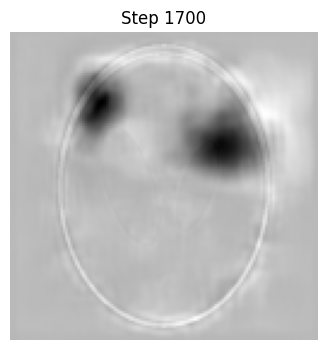

Step  1710, Loss: 6.5035e-02
Step  1720, Loss: 1.3743e-01
Step  1730, Loss: 1.9923e-01
Step  1740, Loss: 1.1976e-01
Step  1750, Loss: 8.6982e-02
Step  1760, Loss: 5.6621e-02
Step  1770, Loss: 4.7013e-02
Step  1780, Loss: 4.1725e-02
Step  1790, Loss: 3.8352e-02
Step  1800, Loss: 4.0252e-02


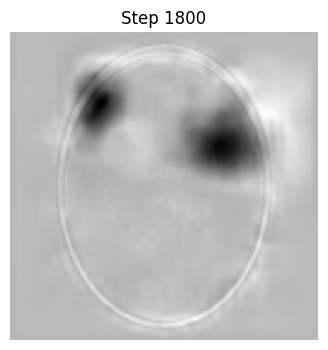

Step  1810, Loss: 3.5387e-02
Step  1820, Loss: 3.2146e-02
Step  1830, Loss: 3.1674e-02
Step  1840, Loss: 3.8557e-02
Step  1850, Loss: 3.3770e-02
Step  1860, Loss: 2.6834e-02
Step  1870, Loss: 2.6710e-02
Step  1880, Loss: 2.5074e-02
Step  1890, Loss: 3.2862e-02
Step  1900, Loss: 2.4144e-02


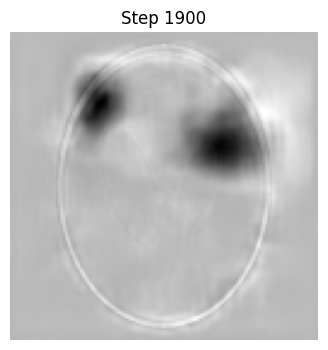

Step  1910, Loss: 3.7751e-02
Step  1920, Loss: 3.1760e-02
Step  1930, Loss: 2.6711e-02
Step  1940, Loss: 2.5842e-02
Step  1950, Loss: 2.2135e-02
Step  1960, Loss: 2.6910e-02
Step  1970, Loss: 2.4615e-02
Step  1980, Loss: 1.9860e-02
Step  1990, Loss: 3.1667e-01
Step  2000, Loss: 1.9585e-01


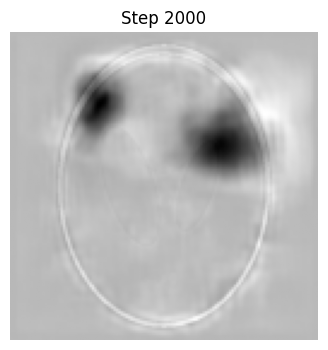

Step  2010, Loss: 8.5003e-02
Step  2020, Loss: 4.3437e-02
Step  2030, Loss: 2.3888e-02
Step  2040, Loss: 1.7925e-02
Step  2050, Loss: 1.4813e-02
Step  2060, Loss: 1.3233e-02
Step  2070, Loss: 1.2516e-02
Step  2080, Loss: 1.1804e-02
Step  2090, Loss: 1.2741e-02
Step  2100, Loss: 1.1553e-02


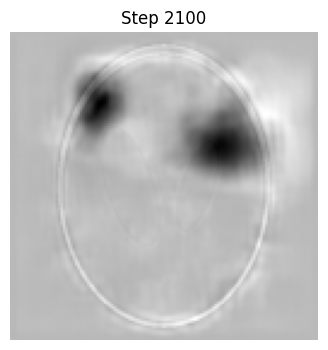

Step  2110, Loss: 1.0572e-02
Step  2120, Loss: 4.3236e-02
Step  2130, Loss: 1.7573e-02
Step  2140, Loss: 1.1232e-02
Step  2150, Loss: 1.1139e-02
Step  2160, Loss: 9.3301e-03
Step  2170, Loss: 8.7332e-03
Step  2180, Loss: 1.1352e-02
Step  2190, Loss: 1.0971e-01
Step  2200, Loss: 6.3555e-02


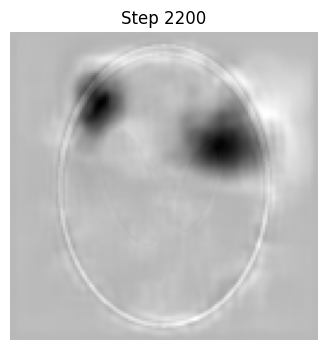

Step  2210, Loss: 3.7685e-02
Step  2220, Loss: 4.3385e-02
Step  2230, Loss: 2.9744e-02
Step  2240, Loss: 3.5169e-02
Step  2250, Loss: 2.2438e-02
Step  2260, Loss: 9.7193e-03
Step  2270, Loss: 1.0406e-02
Step  2280, Loss: 1.0723e-01
Step  2290, Loss: 5.5632e-01
Step  2300, Loss: 4.7645e-01


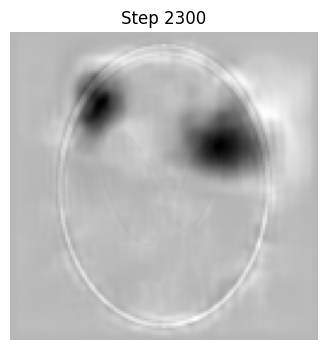

Step  2310, Loss: 1.4277e-01
Step  2320, Loss: 7.4921e-02
Step  2330, Loss: 3.2909e-02
Step  2340, Loss: 1.6661e-02
Step  2350, Loss: 9.8485e-03
Step  2360, Loss: 7.7658e-03
Step  2370, Loss: 6.6933e-03
Step  2380, Loss: 6.1554e-03
Step  2390, Loss: 5.6714e-03
Step  2400, Loss: 5.2274e-03


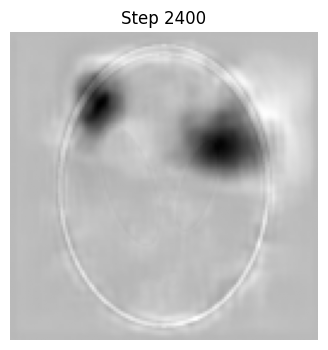

Step  2410, Loss: 7.8681e-03
Step  2420, Loss: 5.5222e-03
Step  2430, Loss: 4.9833e-03
Step  2440, Loss: 4.4576e-03
Step  2450, Loss: 4.4861e-03
Step  2460, Loss: 5.1457e-03
Step  2470, Loss: 1.0760e-02
Step  2480, Loss: 8.3634e-03
Step  2490, Loss: 6.1370e-03
Step  2500, Loss: 5.4717e-03


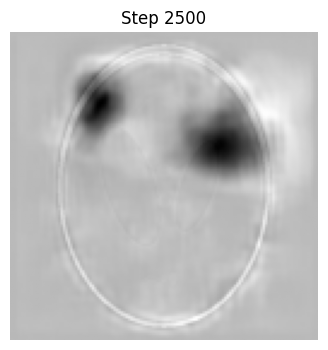

Step  2510, Loss: 4.5793e-03
Step  2520, Loss: 5.5363e-03
Step  2530, Loss: 5.0482e-03
Step  2540, Loss: 4.5874e-03
Step  2550, Loss: 5.2920e-03
Step  2560, Loss: 4.9393e-03
Step  2570, Loss: 4.2950e-03
Step  2580, Loss: 8.9446e-03
Step  2590, Loss: 5.4092e-03
Step  2600, Loss: 4.8130e-03


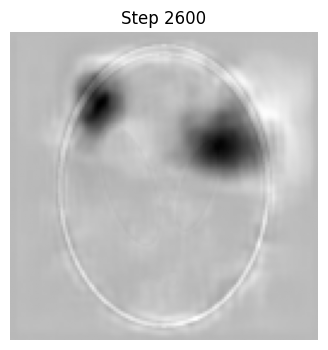

Step  2610, Loss: 7.9684e-03
Step  2620, Loss: 5.4576e-03
Step  2630, Loss: 3.5182e-02
Step  2640, Loss: 2.3607e-02
Step  2650, Loss: 3.2731e-02
Step  2660, Loss: 2.1112e-02
Step  2670, Loss: 1.2801e-02
Step  2680, Loss: 6.3209e-03
Step  2690, Loss: 5.1601e-03
Step  2700, Loss: 3.3127e-02


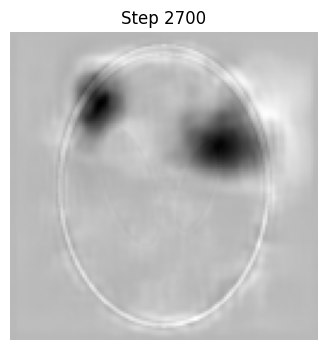

Step  2710, Loss: 1.2380e-01
Step  2720, Loss: 2.5505e-02
Step  2730, Loss: 1.7812e-02
Step  2740, Loss: 1.1992e-02
Step  2750, Loss: 5.0650e-03
Step  2760, Loss: 5.1880e-03
Step  2770, Loss: 2.3730e-02
Step  2780, Loss: 1.4391e+00
Step  2790, Loss: 1.1363e+00
Step  2800, Loss: 3.7968e-01


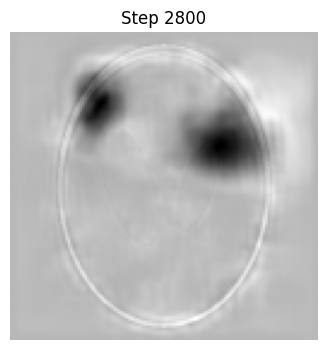

Step  2810, Loss: 1.4649e-01
Step  2820, Loss: 7.7901e-02
Step  2830, Loss: 3.2175e-02
Step  2840, Loss: 2.1603e-02
Step  2850, Loss: 1.1955e-02
Step  2860, Loss: 1.1063e-02
Step  2870, Loss: 1.4725e-02
Step  2880, Loss: 8.6336e-03
Step  2890, Loss: 5.4171e-03
Step  2900, Loss: 1.4455e-02


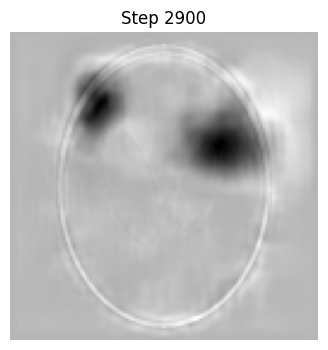

Step  2910, Loss: 7.5348e-03
Step  2920, Loss: 1.1240e-02
Step  2930, Loss: 5.5264e-03
Step  2940, Loss: 4.1480e-03
Step  2950, Loss: 1.1032e-02
Step  2960, Loss: 1.9838e-01
Step  2970, Loss: 7.8903e-02
Step  2980, Loss: 2.5453e-02
Step  2990, Loss: 9.5920e-03
Step  3000, Loss: 5.4317e-03


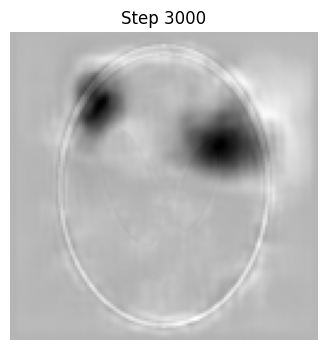

Step  3010, Loss: 3.5366e-03
Step  3020, Loss: 2.5683e-03
Step  3030, Loss: 4.5235e-03
Step  3040, Loss: 3.3631e-03
Step  3050, Loss: 2.3216e-03
Step  3060, Loss: 3.0864e-03
Step  3070, Loss: 3.8083e-02
Step  3080, Loss: 4.6761e-01
Step  3090, Loss: 5.5598e-02
Step  3100, Loss: 3.2425e-02


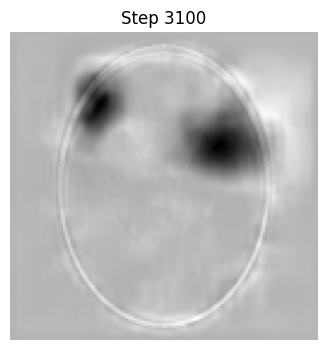

Step  3110, Loss: 1.2768e-02
Step  3120, Loss: 4.6195e-03
Step  3130, Loss: 4.2624e-03
Step  3140, Loss: 2.0698e-03
Step  3150, Loss: 2.0062e-03
Step  3160, Loss: 1.4526e-03
Step  3170, Loss: 2.5876e-03
Step  3180, Loss: 2.7498e-03
Step  3190, Loss: 5.0611e-03
Step  3200, Loss: 4.2194e-03


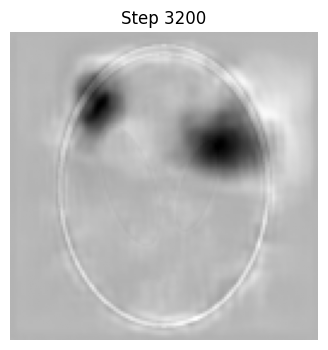

Step  3210, Loss: 8.4631e-03
Step  3220, Loss: 5.5126e-02
Step  3230, Loss: 1.7805e-01
Step  3240, Loss: 3.1394e-02
Step  3250, Loss: 2.8184e-02
Step  3260, Loss: 1.3514e-02
Step  3270, Loss: 4.2047e-03
Step  3280, Loss: 1.0952e-02
Step  3290, Loss: 2.5471e-02
Step  3300, Loss: 8.0031e-03


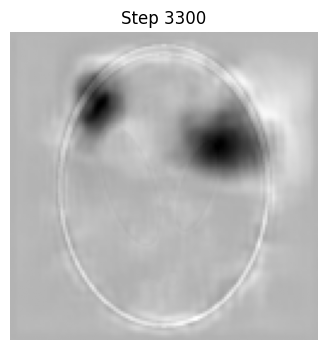

Step  3310, Loss: 1.9657e-03
Step  3320, Loss: 7.7521e-03
Step  3330, Loss: 2.1478e-01
Step  3340, Loss: 1.1527e+00
Step  3350, Loss: 6.5632e-01
Step  3360, Loss: 2.8435e-01
Step  3370, Loss: 1.2524e-01
Step  3380, Loss: 4.7395e-02
Step  3390, Loss: 2.1553e-02
Step  3400, Loss: 1.3645e-02


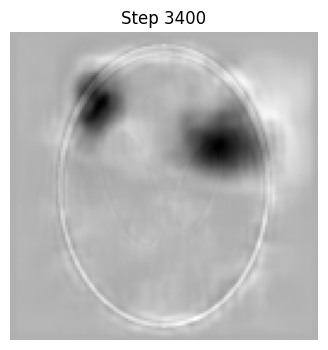

Step  3410, Loss: 7.8375e-03
Step  3420, Loss: 5.6165e-03
Step  3430, Loss: 7.0614e-03
Step  3440, Loss: 5.1977e-03
Step  3450, Loss: 4.1323e-03
Step  3460, Loss: 2.9831e-03
Step  3470, Loss: 2.0860e-03
Step  3480, Loss: 5.7530e-03
Step  3490, Loss: 2.6417e-03
Step  3500, Loss: 1.9457e-03


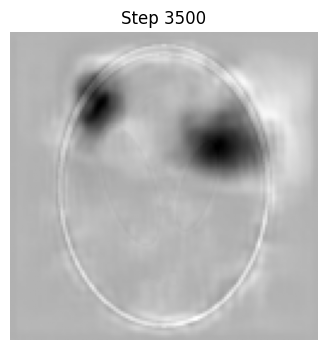

Step  3510, Loss: 2.3179e-03
Step  3520, Loss: 2.1174e-03
Step  3530, Loss: 1.2704e-03
Step  3540, Loss: 1.6134e-03
Step  3550, Loss: 1.1235e-02
Step  3560, Loss: 4.0160e-03
Step  3570, Loss: 4.2305e-03
Step  3580, Loss: 4.4129e-03
Step  3590, Loss: 1.0705e-02
Step  3600, Loss: 7.0544e-03


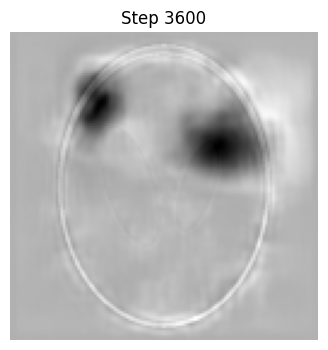

Step  3610, Loss: 2.3541e-03
Step  3620, Loss: 1.7457e-03
Step  3630, Loss: 2.2646e-02
Step  3640, Loss: 1.4320e-01
Step  3650, Loss: 4.0704e-02
Step  3660, Loss: 1.3753e-02
Step  3670, Loss: 9.1629e-03
Step  3680, Loss: 3.6905e-03
Step  3690, Loss: 2.4701e-03
Step  3700, Loss: 2.5669e-03


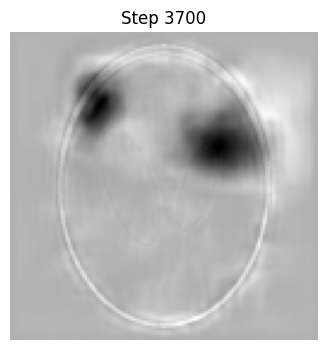

Step  3710, Loss: 2.6086e-03
Step  3720, Loss: 2.6416e-02
Step  3730, Loss: 1.3696e-01
Step  3740, Loss: 1.6968e-02
Step  3750, Loss: 1.2549e-02
Step  3760, Loss: 1.1676e-02
Step  3770, Loss: 3.6270e-03
Step  3780, Loss: 3.7632e-03
Step  3790, Loss: 5.9182e-03
Step  3800, Loss: 3.5631e-02


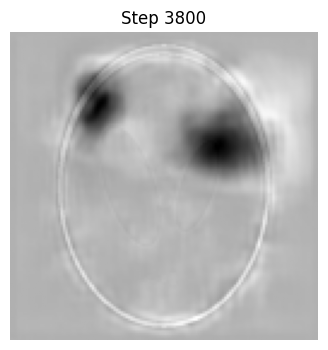

Step  3810, Loss: 3.5030e-01
Step  3820, Loss: 9.4217e-02
Step  3830, Loss: 4.4126e-02
Step  3840, Loss: 2.4049e-02
Step  3850, Loss: 1.1725e-02
Step  3860, Loss: 7.5742e-03
Step  3870, Loss: 6.5956e-03
Step  3880, Loss: 2.0147e-02
Step  3890, Loss: 2.9616e-02
Step  3900, Loss: 2.3084e-02


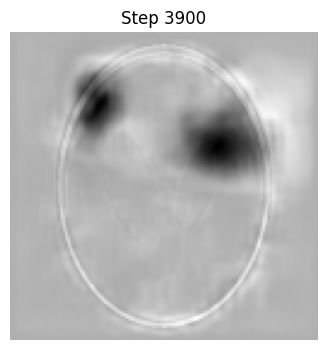

Step  3910, Loss: 4.4836e-03
Step  3920, Loss: 6.2435e-03
Step  3930, Loss: 2.1477e-02


KeyboardInterrupt: 

In [33]:
import optax
import matplotlib.pyplot as plt

# Optimizer
optimizer = nnx.Optimizer(
    model=model,
    tx=optax.adam(1e-3),
    wrt=nnx.Param
)

n_steps = 10_000
losses = []

for step in range(n_steps):
    # Compute loss and grads
    loss, grads = nnx.value_and_grad(loss_fn)(model)

    # Update model parameters
    optimizer.update(model, grads)

    losses.append(loss)

    # Logging
    if step % 10 == 0:
        print(f"Step {step:5d}, Loss: {loss:.4e}")

    # Visualization (use inference mode)
    if step % 100 == 0:
        x_reco = model(z, training=False)[0, :, :, 0]
        plt.figure(figsize=(4,4))
        plt.imshow(x_reco, cmap='gray')
        plt.title(f"Step {step}")
        plt.axis('off')
        plt.show()